In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import pathlib

# Read Excel File 

In [3]:
df = pd.read_excel('2024-02-15-cfu.xlsx')

## Plot Absolute Survival Values

Bar plot showing survival of each strain with Δ5183 reference line

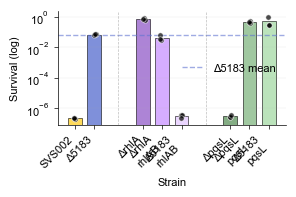

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Chartosaur style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['ytick.major.size'] = 3
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Group strains into 3 categories
group1 = ['SVS002', '∆5183']
group2 = ['∆rhlA', '∆rhlA pQFT rhlAB', '∆5183 pQFT rhlAB']
group3 = ['∆pqsL', '∆pqsL pQFT pqsL', '∆5183 pQFT pqsL']

# Colors for each group
# Group 1: neutral colors
colors_g1 = ['#ffd332', '#5f74d1']
# Group 2: purple/magenta tones (#cc99ff)
colors_g2 = ['#9966CC', '#CC99FF', '#E6CCFF']
# Group 3: green tones (#669966)
colors_g3 = ['#669966', '#88BB88', '#AADDAA']

timepoint = '8h'

fig, ax = plt.subplots(figsize=(3, 2))

bar_width = 0.7
gap = 1.5  # Gap between groups

# Calculate positions for each group
pos_g1 = np.arange(len(group1))
pos_g2 = np.arange(len(group2)) + len(group1) + gap
pos_g3 = np.arange(len(group3)) + len(group1) + len(group2) + 2*gap

all_positions = np.concatenate([pos_g1, pos_g2, pos_g3])
all_strains = group1 + group2 + group3
all_colors = colors_g1 + colors_g2 + colors_g3

# Get the Δ5183 mean value for the horizontal line
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]
if len(df_5183) > 0:
    delta_5183_mean = df_5183['Survival'].mean()
else:
    delta_5183_mean = None

for i, (pos, donor, color) in enumerate(zip(all_positions, all_strains, all_colors)):
    # Filter data for this donor and timepoint
    df_subset = df[(df['Donor'] == donor) & (df['Timepoint'] == timepoint)]
    
    if len(df_subset) > 0:
        # Calculate mean
        mean_val = df_subset['Survival'].mean()
        
        # Plot bar
        ax.bar(pos, mean_val, bar_width,
               color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Overlay individual data points
        y_values = df_subset['Survival'].values
        x_jitter = np.random.normal(pos, 0.05, len(y_values))
        
        ax.scatter(x_jitter, y_values, 
                  color='black', s=15, alpha=0.7, zorder=3, 
                  edgecolors='white', linewidths=0.5)

# Add horizontal line at Δ5183 level
if delta_5183_mean is not None:
    ax.axhline(delta_5183_mean, color='#5f74d1', linestyle='--', 
               linewidth=1, alpha=0.6, zorder=1, label = 'Δ5183 mean')


# Format plot
ax.set_ylabel('Survival (log)', fontsize=8)
ax.set_xlabel('Strain', fontsize=8)
ax.set_yscale('log')

# Set x-axis labels with grouping
ax.set_xticks(all_positions)
labels = [s.replace('∆', 'Δ').replace(' pQFT ', '\n') for s in all_strains]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)

# Add vertical lines to separate groups
group_sep_1 = (pos_g1[-1] + pos_g2[0]) / 2
group_sep_2 = (pos_g2[-1] + pos_g3[0]) / 2
ax.axvline(group_sep_1, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(group_sep_2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Chartosaur style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.25, axis='y')
ax.tick_params(axis='both', labelsize=8)

# Add legend on two columns
ax.legend(frameon=False, fontsize=8, loc = 'best') 

plt.tight_layout()
plt.savefig('1SA_batch_tolerance.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Plot Fold Change Relative to Δ5183

Bar plot showing fold change of each mutant/complemented strain relative to Δ5183 baseline

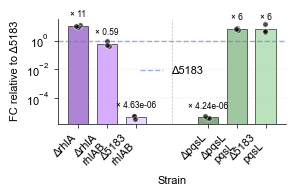

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Chartosaur style
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 3
plt.rcParams['ytick.major.size'] = 3
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Group strains into 2 categories (excluding SVS002 and Δ5183)
group2 = ['∆rhlA', '∆rhlA pQFT rhlAB', '∆5183 pQFT rhlAB']
group3 = ['∆pqsL', '∆pqsL pQFT pqsL', '∆5183 pQFT pqsL']

# Colors for each group
colors_g2 = ['#9966CC', '#CC99FF', '#E6CCFF']
colors_g3 = ['#669966', '#88BB88', '#AADDAA']

timepoint = '8h'

fig, ax = plt.subplots(figsize=(3, 2))
bar_width = 0.7
gap = 1.5

# Calculate positions for each group
pos_g2 = np.arange(len(group2))
pos_g3 = np.arange(len(group3)) + len(group2) + gap
all_positions = np.concatenate([pos_g2, pos_g3])
all_strains = group2 + group3
all_colors = colors_g2 + colors_g3

# Get the Δ5183 mean value as reference
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]
if len(df_5183) > 0:
    delta_5183_mean = df_5183['Survival'].mean()
else:
    delta_5183_mean = None
    print("Warning: No data for Δ5183")

# Plot bars with fold change
for i, (pos, donor, color) in enumerate(zip(all_positions, all_strains, all_colors)):
    df_subset = df[(df['Donor'] == donor) & (df['Timepoint'] == timepoint)]
    
    if len(df_subset) > 0 and delta_5183_mean is not None:
        # CORRECTED: Calculate geometric mean of fold change
        # Calculate FC for each replicate (all use same delta_5183_mean)
        individual_fcs = df_subset['Survival'].values / delta_5183_mean
        
        # Convert to log2 space, average, then convert back (geometric mean)
        log2_fcs = np.log2(individual_fcs)
        mean_log2_fc = np.mean(log2_fcs)
        fold_change = 2**mean_log2_fc  # Geometric mean
        
        # Plot bar
        ax.bar(pos, fold_change, bar_width,
               color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Calculate fold change for individual replicates (unchanged)
        y_values = individual_fcs  # Already calculated above
        x_jitter = np.random.normal(pos, 0.05, len(y_values))
        ax.scatter(x_jitter, y_values, 
                   color='black', s=15, alpha=0.7, zorder=3, 
                   edgecolors='white', linewidths=0.5)
        
        # Add fold change text annotation
        if fold_change >= 1:
            label_text = f'× {fold_change:.0f}'
        elif fold_change >= 0.01:
            label_text = f'× {fold_change:.2f}'
        else:
            label_text = f'× {fold_change:.2e}'
        
        # Position text above bar
        y_text = fold_change * 3  # Slightly above the bar
        ax.text(pos, y_text, label_text, 
                ha='center', va='bottom', fontsize=6, fontweight='normal')

# Add horizontal line at fold change = 1 (Δ5183 level)
ax.axhline(1, color='#5f74d1', linestyle='--', 
           linewidth=1, alpha=0.6, zorder=1, label='Δ5183')

# Format plot
ax.set_ylabel('FC relative to Δ5183', fontsize=8)
ax.set_xlabel('Strain', fontsize=8)
ax.set_yscale('log')

# Set x-axis labels
ax.set_xticks(all_positions)
labels = [s.replace('∆', 'Δ').replace(' pQFT ', '\n') for s in all_strains]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=6)

# Add vertical line to separate groups
group_sep = (pos_g2[-1] + pos_g3[0]) / 2
ax.axvline(group_sep, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Chartosaur style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linewidth=0.25, axis='y')
ax.tick_params(axis='both', labelsize=8)

# Add legend for the reference line
ax.legend(fontsize=8, frameon=False, loc='best')

plt.tight_layout()
plt.savefig('1SB_batch_tolerance_FC.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Statistical Analysis

One-sample t-test on log2 fold changes with Bonferroni correction to determine which strains significantly differ from Δ5183

In [10]:
import pandas as pd
import numpy as np
from scipy import stats

timepoint = '8h'

# Define groups
group2 = ['∆rhlA', '∆rhlA pQFT rhlAB', '∆5183 pQFT rhlAB']
group3 = ['∆pqsL', '∆pqsL pQFT pqsL', '∆5183 pQFT pqsL']
all_strains = group2 + group3

# Get reference (Δ5183) values for each replicate
df_5183 = df[(df['Donor'] == '∆5183') & (df['Timepoint'] == timepoint)]

# Calculate fold changes for EACH BIOLOGICAL REPLICATE
fold_change_data = []

for strain in all_strains:
    df_strain = df[(df['Donor'] == strain) & (df['Timepoint'] == timepoint)]
    
    # For each biological replicate, calculate fold change
    for idx, row in df_strain.iterrows():
        # Get corresponding Δ5183 value (same replicate if paired, or mean if not)
        if 'Replicate' in df.columns and row['Replicate'] in df_5183['Replicate'].values:
            # Paired design: use same replicate
            ref_value = df_5183[df_5183['Replicate'] == row['Replicate']]['Survival'].values[0]
        else:
            # Unpaired: use mean of reference
            ref_value = df_5183['Survival'].mean()
        
        fc = row['Survival'] / ref_value
        log2_fc = np.log2(fc) if fc > 0 else np.nan
        
        fold_change_data.append({
            'Strain': strain,
            'Survival': row['Survival'],
            'FoldChange': fc,
            'Log2FC': log2_fc,
            'Replicate': row.get('Replicate', idx)
        })

df_fc = pd.DataFrame(fold_change_data)

# Remove any NaN values
df_fc = df_fc.dropna(subset=['Log2FC'])

# ============================================================================
# STATISTICAL ANALYSIS
# Compare each strain to Δ5183 (reference)
# Use one-sample t-test on log2 fold changes (test if mean log2FC ≠ 0)
# ============================================================================

results = []
for strain in all_strains:
    log2fc_values = df_fc[df_fc['Strain'] == strain]['Log2FC'].values
    
    if len(log2fc_values) >= 3:  # Need at least 3 replicates
        # Test if log2FC is significantly different from 0
        t_stat, p_value = stats.ttest_1samp(log2fc_values, 0)
        
        results.append({
            'Strain': strain,
            'Mean_Log2FC': np.mean(log2fc_values),
            'Mean_FC': 2**np.mean(log2fc_values),  # Convert back to fold change
            'p_value': p_value,
            't_statistic': t_stat,
            'n': len(log2fc_values)
        })

df_stats = pd.DataFrame(results)

# Apply multiple testing correction (Bonferroni)
df_stats['p_adjusted'] = df_stats['p_value'] * len(df_stats)
df_stats['p_adjusted'] = df_stats['p_adjusted'].clip(upper=1.0)

# Add significance stars
def add_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

df_stats['significance'] = df_stats['p_adjusted'].apply(add_stars)

print("\n" + "="*80)
print("STATISTICAL TEST: One-sample t-test on Log₂(Fold Change)")
print("="*80)
print("Null hypothesis: Mean Log₂FC = 0 (i.e., FC = 1, no difference from Δ5183)")
print("Alternative: Mean Log₂FC ≠ 0 (i.e., FC ≠ 1, different from Δ5183)")
print("Multiple testing correction: Bonferroni")
print("="*80 + "\n")

print("Statistical Results:")
print(df_stats[['Strain', 'Mean_FC', 'Mean_Log2FC', 'p_adjusted', 'significance']].to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("* p < 0.05   → Strain differs from Δ5183")
print("ns           → No significant difference from Δ5183")
print("Mean_FC > 1  → Higher survival than Δ5183")
print("Mean_FC < 1  → Lower survival than Δ5183")
print("="*80 + "\n")


STATISTICAL TEST: One-sample t-test on Log₂(Fold Change)
Null hypothesis: Mean Log₂FC = 0 (i.e., FC = 1, no difference from Δ5183)
Alternative: Mean Log₂FC ≠ 0 (i.e., FC ≠ 1, different from Δ5183)
Multiple testing correction: Bonferroni

Statistical Results:
          Strain   Mean_FC  Mean_Log2FC  p_adjusted significance
           ∆rhlA 10.684819     3.417491    0.012770            *
∆rhlA pQFT rhlAB  0.593109    -0.753632    0.960462           ns
∆5183 pQFT rhlAB  0.000005   -17.719780    0.000978          ***
           ∆pqsL  0.000004   -17.846196    0.000307          ***
 ∆pqsL pQFT pqsL  6.386320     2.674985    0.021055            *
 ∆5183 pQFT pqsL  6.447150     2.688662    0.290988           ns

INTERPRETATION:
* p < 0.05   → Strain differs from Δ5183
ns           → No significant difference from Δ5183
Mean_FC > 1  → Higher survival than Δ5183
Mean_FC < 1  → Lower survival than Δ5183

